In [ ]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import glob
import os



In [ ]:

file_paths = ['/JPM.csv', '/MSFT.csv', '/SNY.csv', '/VZ.csv', '/WBD.csv']
dataframes = []

for path in file_paths:
    df = pd.read_csv(path)
    df = df[['Date', 'close']]
    stock_name = os.path.splitext(os.path.basename(path))[0]
    df.rename(columns={'close': f'{stock_name}_close'}, inplace=True)
    dataframes.append(df)

# Merge on Date
merged_df = dataframes[0]
for df in dataframes[1:]:
    merged_df = pd.merge(merged_df, df, on='Date')

merged_df['Date'] = pd.to_datetime(merged_df['Date'])
merged_df.sort_values('Date', inplace=True)
merged_df.reset_index(drop=True, inplace=True)
merged_df.dropna(inplace=True)  # remove rows with missing data

print(merged_df.head())


                 Date  JPM_close  MSFT_close  SNY_close  VZ_close  WBD_close
0 2024-01-02 05:00:00     172.08      370.87      50.00     38.88      11.66
1 2024-01-03 05:00:00     171.33      370.60      50.61     39.16      11.30
2 2024-01-04 05:00:00     171.41      367.94      51.01     39.37      11.35
3 2024-01-05 05:00:00     172.27      367.75      51.21     40.20      11.20
4 2024-01-08 05:00:00     172.02      374.69      51.99     40.10      11.40


In [ ]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(merged_df.drop('Date', axis=1))

SEQ_LEN = 20  # number of time steps in input
PRED_LEN = 1  # predict one step ahead

def create_sequences(data, seq_len=SEQ_LEN, pred_len=PRED_LEN):
    X, y = [], []
    for i in range(len(data) - seq_len - pred_len + 1):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len:i+seq_len+pred_len, 0])  # Predict JPM only
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data)

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

#normalizes the stock data, then creates training sequences by sliding a window of SEQ_LEN (20) time steps
#and extracting the next time step's JPM closing price (column 0) as the target for each sequence.
#It then converts the resulting arrays into PyTorch tensors for model training.


In [ ]:
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = StockDataset(X_tensor, y_tensor)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

#splitting to training and testing.
#X (past 20 days of prices) and labels y (next-day prices).
#80 20 split.


In [ ]:
class TransformerModel(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.decoder = nn.Linear(d_model, 1)

    def forward(self, src):
        src = self.embedding(src)
        src = src.permute(1, 0, 2)
        output = self.transformer_encoder(src)
        out = self.decoder(output[-1])
        return out

#Transformer-based neural network model to predict the next stock price

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TransformerModel(input_dim=X.shape[2]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

EPOCHS = 30

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model(X_batch)
        loss = loss_fn(output.squeeze(), y_batch.squeeze())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader):.5f}")

    #trains your Transformer model for 30 epochs


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1, Loss: 0.11149
Epoch 2, Loss: 0.02940
Epoch 3, Loss: 0.01365
Epoch 4, Loss: 0.00931
Epoch 5, Loss: 0.00908
Epoch 6, Loss: 0.00957
Epoch 7, Loss: 0.00694
Epoch 8, Loss: 0.00620
Epoch 9, Loss: 0.00669
Epoch 10, Loss: 0.00610
Epoch 11, Loss: 0.00602
Epoch 12, Loss: 0.00572
Epoch 13, Loss: 0.00613
Epoch 14, Loss: 0.00493
Epoch 15, Loss: 0.00453
Epoch 16, Loss: 0.00458
Epoch 17, Loss: 0.00422
Epoch 18, Loss: 0.00448
Epoch 19, Loss: 0.00384
Epoch 20, Loss: 0.00343
Epoch 21, Loss: 0.00403
Epoch 22, Loss: 0.00427
Epoch 23, Loss: 0.00403
Epoch 24, Loss: 0.00413
Epoch 25, Loss: 0.00406
Epoch 26, Loss: 0.00365
Epoch 27, Loss: 0.00352
Epoch 28, Loss: 0.00313
Epoch 29, Loss: 0.00357
Epoch 30, Loss: 0.00291


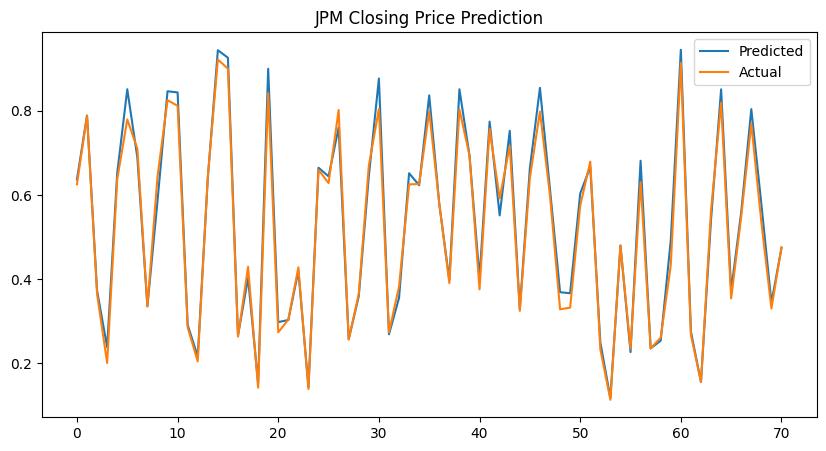

In [ ]:
model.eval()
predictions, actuals = [], []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        pred = model(X_batch).cpu().numpy()
        predictions.extend(pred)
        actuals.extend(y_batch.numpy())

predictions = np.array(predictions).squeeze()
actuals = np.array(actuals).squeeze()

scaled_jpm = scaled_data[:, 0].reshape(-1, 1)
scaler_jpm = MinMaxScaler()
scaler_jpm.fit(scaled_jpm)

pred_real = scaler_jpm.inverse_transform(predictions.reshape(-1, 1))
actual_real = scaler_jpm.inverse_transform(actuals.reshape(-1, 1))

plt.figure(figsize=(10, 5))
plt.plot(pred_real, label='Predicted')
plt.plot(actual_real, label='Actual')
plt.legend()
plt.title('JPM Closing Price Prediction')
plt.show()

#evaluate trained model

In [ ]:

tick = ['/JPM', '/MSFT', '/SNY', '/VZ', '/WBD']
dfs = []

for ticker in tick:
    df = pd.read_csv(f'{ticker}.csv')[['Date', 'close']]
    df.rename(columns={'close': f'{ticker}_close'}, inplace=True)
    dfs.append(df)

# Merge all on Date
data = dfs[0]
for df in dfs[1:]:
    data = pd.merge(data, df, on='Date')

data['Date'] = pd.to_datetime(data['Date'])
data.sort_values('Date', inplace=True)
data.dropna(inplace=True)
data.reset_index(drop=True, inplace=True)

features = data.drop(columns=['Date']).values


In [ ]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(features)

SEQ_LEN = 20  # history steps
PRED_LEN = 1  # 1-step ahead prediction

def create_sequences(data, seq_len, pred_len):
    X, y = [], []
    for i in range(len(data) - seq_len - pred_len + 1):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len:i+seq_len+pred_len])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled, SEQ_LEN, PRED_LEN)
y = y.squeeze(axis=1)  # shape: (samples, 5)


In [ ]:
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = StockDataset(X_tensor, y_tensor)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)


In [ ]:
class MultiStockTransformer(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, dropout=0.1, output_dim=5):
        super().__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.decoder = nn.Linear(d_model, output_dim)

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(1, 0, 2)  # [seq_len, batch, dim]
        encoded = self.transformer(x)
        out = self.decoder(encoded[-1])  # Use last token output
        return out


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MultiStockTransformer(input_dim=5, output_dim=5).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

EPOCHS = 30

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader):.5f}")


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1, Loss: 0.24662
Epoch 2, Loss: 0.08477
Epoch 3, Loss: 0.03555
Epoch 4, Loss: 0.03328
Epoch 5, Loss: 0.02337
Epoch 6, Loss: 0.02212
Epoch 7, Loss: 0.01860
Epoch 8, Loss: 0.01631
Epoch 9, Loss: 0.01565
Epoch 10, Loss: 0.01481
Epoch 11, Loss: 0.01419
Epoch 12, Loss: 0.01222
Epoch 13, Loss: 0.01306
Epoch 14, Loss: 0.01282
Epoch 15, Loss: 0.01145
Epoch 16, Loss: 0.01124
Epoch 17, Loss: 0.01095
Epoch 18, Loss: 0.01090
Epoch 19, Loss: 0.01050
Epoch 20, Loss: 0.01072
Epoch 21, Loss: 0.00990
Epoch 22, Loss: 0.00980
Epoch 23, Loss: 0.01004
Epoch 24, Loss: 0.00997
Epoch 25, Loss: 0.00941
Epoch 26, Loss: 0.00969
Epoch 27, Loss: 0.00913
Epoch 28, Loss: 0.00906
Epoch 29, Loss: 0.00900
Epoch 30, Loss: 0.00852


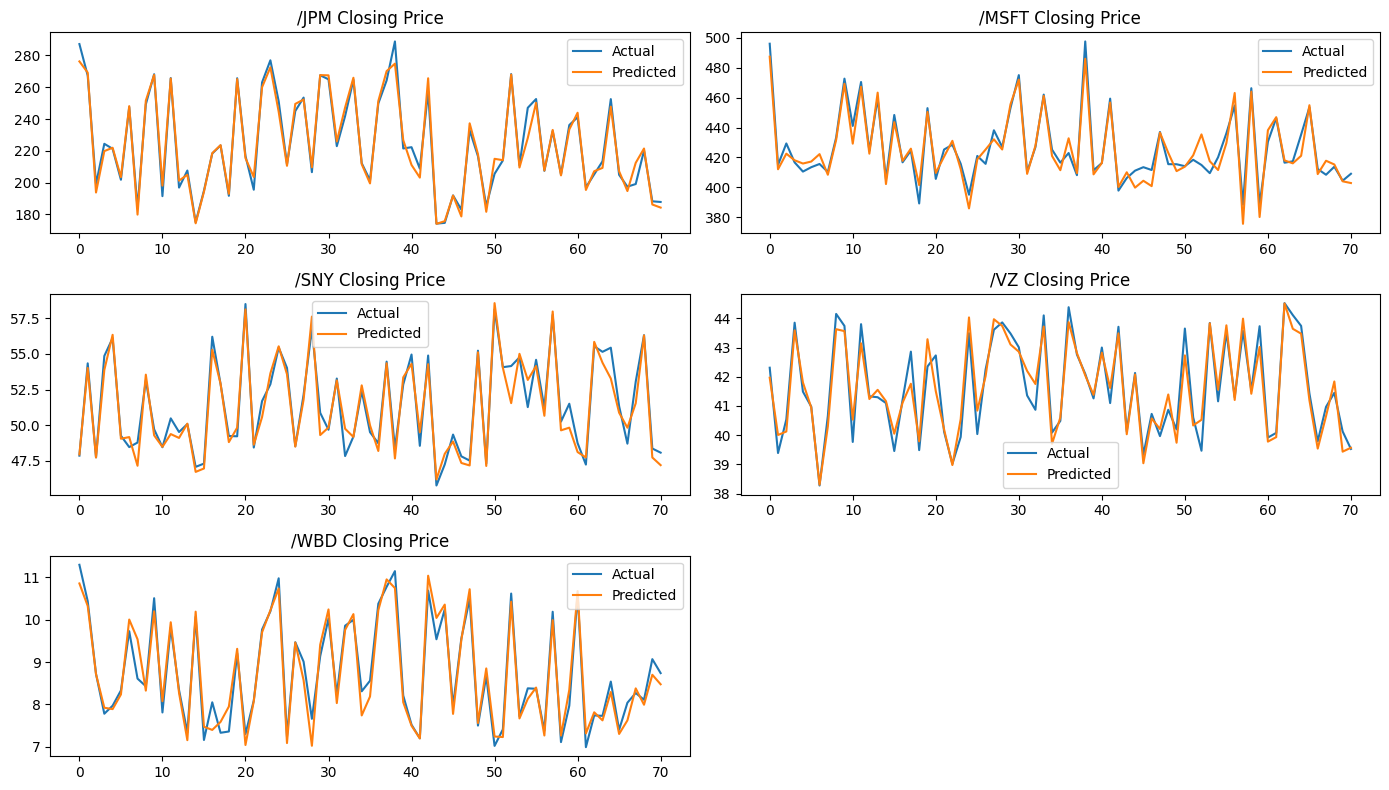

In [ ]:
model.eval()
preds, actuals = [], []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        output = model(X_batch).cpu().numpy()
        preds.append(output)
        actuals.append(y_batch.numpy())

preds = np.concatenate(preds)
actuals = np.concatenate(actuals)

# Inverse scale
preds_inv = scaler.inverse_transform(preds)
actuals_inv = scaler.inverse_transform(actuals)

# Plot for each stock
plt.figure(figsize=(14, 8))
for i, ticker in enumerate(tick):
    plt.subplot(3, 2, i+1)
    plt.plot(actuals_inv[:, i], label='Actual')
    plt.plot(preds_inv[:, i], label='Predicted')
    plt.title(f'{ticker} Closing Price')
    plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
#next 5 days
model.eval()


recent_sequence = torch.tensor(scaled[-SEQ_LEN:], dtype=torch.float32).unsqueeze(0).to(device)  # shape: [1, 20, 5]

future_predictions = []

with torch.no_grad():
    for _ in range(5):  # Predict next 5 days
        out = model(recent_sequence).squeeze(0)  # shape: [5]
        future_predictions.append(out.cpu().numpy())


        next_input = out.unsqueeze(0).unsqueeze(0).to(device)  # [1, 1, 5]
        recent_sequence = torch.cat([recent_sequence[:, 1:, :], next_input], dim=1)  # keep SEQ_LEN length


future_predictions = np.array(future_predictions)  # [5, 5]
future_real = scaler.inverse_transform(future_predictions)

# results
import datetime

last_date = data['Date'].iloc[-1]
next_dates = [last_date + datetime.timedelta(days=i+1) for i in range(5)]

forecast_df = pd.DataFrame(future_real, columns=[f'{t}_predicted' for t in tick])
forecast_df.insert(0, 'Date', next_dates)
print(forecast_df)


                 Date  /JPM_predicted  /MSFT_predicted  /SNY_predicted  \
0 2025-06-28 04:00:00      275.372375       486.621796       47.638401   
1 2025-06-29 04:00:00      271.405212       481.431641       47.600330   
2 2025-06-30 04:00:00      270.050171       478.315948       47.614750   
3 2025-07-01 04:00:00      269.602600       476.337738       47.640110   
4 2025-07-02 04:00:00      269.479828       474.983673       47.663219   

   /VZ_predicted  /WBD_predicted  
0      42.062096       10.982384  
1      41.906353       10.869644  
2      41.778469       10.833124  
3      41.657131       10.823938  
4      41.539997       10.821639  
